In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [8]:
df = pd.read_csv('/content/spam_email_dataset.csv')

print(df.head())
print(df.shape)

   email_id           subject  \
0         0     Weekly Report   
1         1    Project Update   
2         2    🔥WIN BIG NOW!!   
3         3    🔥WIN BIG NOW!!   
4         4  Meeting Reminder   

                                          email_text  num_words  \
0  budget review - Statement our I claim world st...         19   
1  team sync - President series today already. In...         18   
2  win free urgent offer limited limited urgent u...         19   
3  guarantee click now cash offer click now guara...         16   
4  team sync - Significant property hotel not add...         18   

   num_characters  num_exclamation_marks  num_links  has_suspicious_link  \
0             114                      0          2                    0   
1             114                      0          7                    0   
2             126                      0          4                    1   
3             101                      0          7                    1   
4             111 

In [9]:
print(df.columns)

Index(['email_id', 'subject', 'email_text', 'num_words', 'num_characters',
       'num_exclamation_marks', 'num_links', 'has_suspicious_link',
       'num_attachments', 'has_attachment', 'sender_email', 'sender_domain',
       'sender_reputation_score', 'email_hour', 'email_day_of_week',
       'is_weekend', 'num_recipients', 'contains_money_terms',
       'contains_urgency_terms', 'label'],
      dtype='object')


In [10]:
print(df.head())
print(df.columns)
print(df.shape)

   email_id           subject  \
0         0     Weekly Report   
1         1    Project Update   
2         2    🔥WIN BIG NOW!!   
3         3    🔥WIN BIG NOW!!   
4         4  Meeting Reminder   

                                          email_text  num_words  \
0  budget review - Statement our I claim world st...         19   
1  team sync - President series today already. In...         18   
2  win free urgent offer limited limited urgent u...         19   
3  guarantee click now cash offer click now guara...         16   
4  team sync - Significant property hotel not add...         18   

   num_characters  num_exclamation_marks  num_links  has_suspicious_link  \
0             114                      0          2                    0   
1             114                      0          7                    0   
2             126                      0          4                    1   
3             101                      0          7                    1   
4             111 

In [11]:
print(df['label'].value_counts())

label
0    6005
1    3995
Name: count, dtype: int64


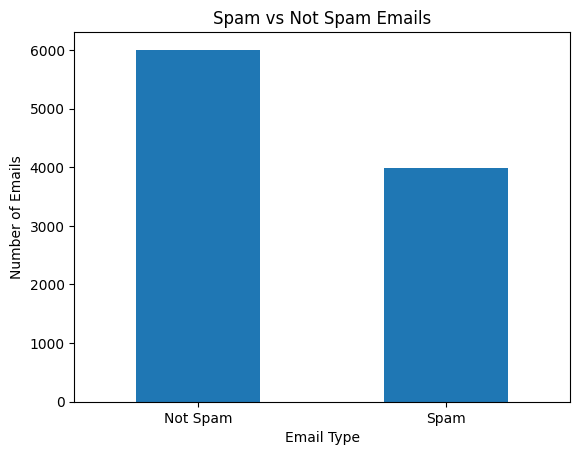

In [12]:
df['label'].value_counts().plot(kind='bar')

plt.xlabel('Email Type')
plt.ylabel('Number of Emails')
plt.title('Spam vs Not Spam Emails')
plt.xticks([0, 1], ['Not Spam', 'Spam'], rotation=0)

plt.show()

In [13]:
print("Missing email text:", df['email_text'].isnull().sum())
print("Missing subjects:", df['subject'].isnull().sum())
print("Missing labels:", df['label'].isnull().sum())

Missing email text: 0
Missing subjects: 0
Missing labels: 0


In [14]:
df['text'] = df['subject'].fillna('') + ' ' + df['email_text'].fillna('')

print(df[['subject', 'email_text', 'text']].head())

            subject                                         email_text  \
0     Weekly Report  budget review - Statement our I claim world st...   
1    Project Update  team sync - President series today already. In...   
2    🔥WIN BIG NOW!!  win free urgent offer limited limited urgent u...   
3    🔥WIN BIG NOW!!  guarantee click now cash offer click now guara...   
4  Meeting Reminder  team sync - Significant property hotel not add...   

                                                text  
0  Weekly Report budget review - Statement our I ...  
1  Project Update team sync - President series to...  
2  🔥WIN BIG NOW!! win free urgent offer limited l...  
3  🔥WIN BIG NOW!! guarantee click now cash offer ...  
4  Meeting Reminder team sync - Significant prope...  


In [15]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [16]:
df['clean_text'] = df['text'].apply(preprocess_text)

print(df[['text', 'clean_text']].head())

                                                text  \
0  Weekly Report budget review - Statement our I ...   
1  Project Update team sync - President series to...   
2  🔥WIN BIG NOW!! win free urgent offer limited l...   
3  🔥WIN BIG NOW!! guarantee click now cash offer ...   
4  Meeting Reminder team sync - Significant prope...   

                                          clean_text  
0  weekly report budget review statement our i cl...  
1  project update team sync president series toda...  
2  win big now win free urgent offer limited limi...  
3  win big now guarantee click now cash offer cli...  
4  meeting reminder team sync significant propert...  


In [17]:
X = df['clean_text']
y = df['label']

print(X.head())
print(y.head())

0    weekly report budget review statement our i cl...
1    project update team sync president series toda...
2    win big now win free urgent offer limited limi...
3    win big now guarantee click now cash offer cli...
4    meeting reminder team sync significant propert...
Name: clean_text, dtype: object
0    0
1    0
2    1
3    1
4    0
Name: label, dtype: int64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training emails:", len(X_train))
print("Testing emails:", len(X_test))

Training emails: 8000
Testing emails: 2000


In [19]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (8000, 985)
Testing TF-IDF shape: (2000, 985)


In [20]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (8000, 985)
Testing TF-IDF shape: (2000, 985)


In [21]:
model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [22]:
y_pred = model.predict(X_test_tfidf)

print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 1 0 0 1 0 1 0 1 0 0 1 1 0 0 0 1 0 0]


In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [24]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Spam', 'Spam']
))

              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00      1201
        Spam       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [25]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1201    0]
 [   0  799]]


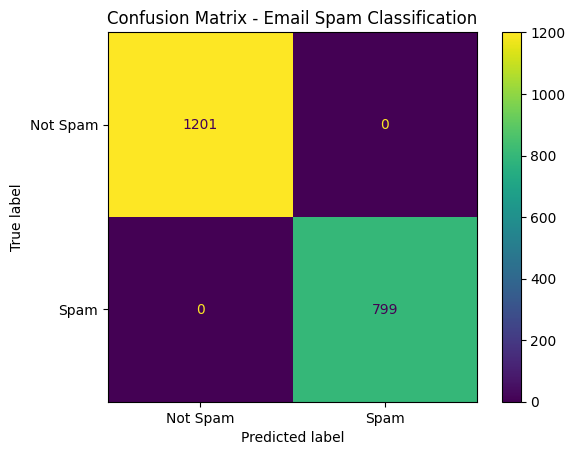

In [26]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Not Spam', 'Spam']
)

plt.title("Confusion Matrix - Email Spam Classification")
plt.show()

In [27]:
new_emails = [
    "Congratulations! You have won $5000. Click here now to claim your prize!",
    "Hi, I wanted to remind you about our meeting tomorrow at 10 AM.",
    "URGENT! You have been selected for a free cash reward. Claim now!",
    "Please send me the project report when you have time."
]

In [28]:
new_emails_clean = [
    preprocess_text(email)
    for email in new_emails
]

print(new_emails_clean)

['congratulations you have won click here now to claim your prize', 'hi i wanted to remind you about our meeting tomorrow at am', 'urgent you have been selected for a free cash reward claim now', 'please send me the project report when you have time']


In [29]:
new_emails_tfidf = vectorizer.transform(new_emails_clean)

predictions = model.predict(new_emails_tfidf)

for email, prediction in zip(new_emails, predictions):
    if prediction == 1:
        print("Spam:", email)
    else:
        print("Not Spam:", email)

Spam: Congratulations! You have won $5000. Click here now to claim your prize!
Not Spam: Hi, I wanted to remind you about our meeting tomorrow at 10 AM.
Spam: URGENT! You have been selected for a free cash reward. Claim now!
Not Spam: Please send me the project report when you have time.


In [30]:
print("Duplicate emails:", df['text'].duplicated().sum())

Duplicate emails: 0


In [31]:
label_check = df.groupby('text')['label'].nunique()

print("Texts with conflicting labels:", (label_check > 1).sum())

Texts with conflicting labels: 0


In [32]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

label
0    6005
1    3995
Name: count, dtype: int64
label
0    60.05
1    39.95
Name: proportion, dtype: float64


In [33]:
from sklearn.feature_extraction.text import CountVectorizer

In [34]:
from sklearn.naive_bayes import MultinomialNB

In [35]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

print(df[['clean_text', 'word_count', 'label']].head())

                                          clean_text  word_count  label
0  weekly report budget review statement our i cl...          20      0
1  project update team sync president series toda...          19      0
2  win big now win free urgent offer limited limi...          22      1
3  win big now guarantee click now cash offer cli...          19      1
4  meeting reminder team sync significant propert...          19      0


In [36]:
print(df['word_count'].describe())

count    10000.000000
mean        19.900200
std          5.676748
min          6.000000
25%         16.000000
50%         20.000000
75%         24.000000
max         37.000000
Name: word_count, dtype: float64


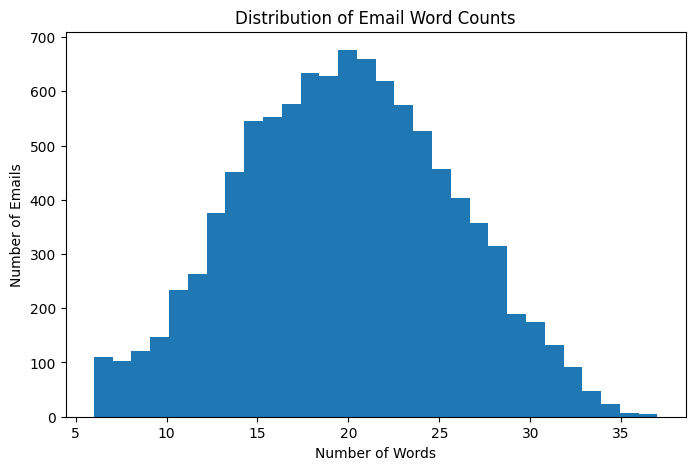

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df['word_count'], bins=30)

plt.xlabel('Number of Words')
plt.ylabel('Number of Emails')
plt.title('Distribution of Email Word Counts')

plt.show()

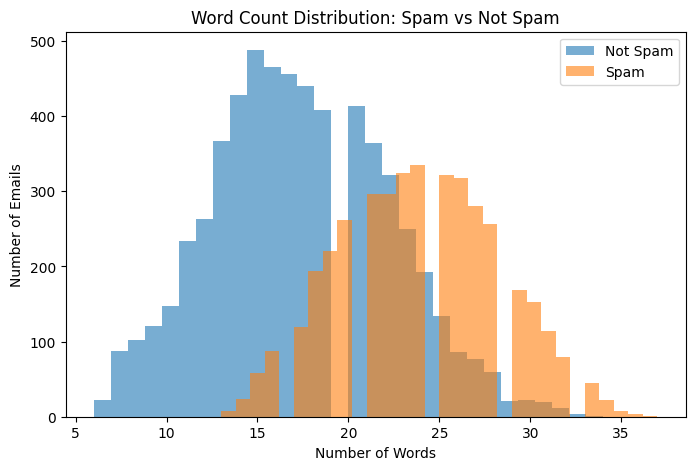

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df['label'] == 0]['word_count'],
    bins=30,
    alpha=0.6,
    label='Not Spam'
)

plt.hist(
    df[df['label'] == 1]['word_count'],
    bins=30,
    alpha=0.6,
    label='Spam'
)

plt.xlabel('Number of Words')
plt.ylabel('Number of Emails')
plt.title('Word Count Distribution: Spam vs Not Spam')
plt.legend()

plt.show()

In [39]:
print("Average word count for Not Spam:",
      df[df['label'] == 0]['word_count'].mean())

print("Average word count for Spam:",
      df[df['label'] == 1]['word_count'].mean())

Average word count for Not Spam: 17.29525395503747
Average word count for Spam: 23.815769712140174


In [40]:
from sklearn.feature_extraction.text import CountVectorizer

In [41]:
count_vectorizer = CountVectorizer()

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("Training Count Vectorizer shape:", X_train_count.shape)
print("Testing Count Vectorizer shape:", X_test_count.shape)

Training Count Vectorizer shape: (8000, 985)
Testing Count Vectorizer shape: (2000, 985)


In [42]:
from sklearn.naive_bayes import MultinomialNB

In [43]:
nb_model_count = MultinomialNB()

nb_model_count.fit(X_train_count, y_train)

print("Multinomial Naive Bayes training completed!")

Multinomial Naive Bayes training completed!


In [44]:
nb_pred_count = nb_model_count.predict(X_test_count)

print("Predictions:")
print(nb_pred_count[:20])

Predictions:
[1 0 1 0 0 1 0 1 0 1 0 0 1 1 0 0 0 1 0 0]


In [45]:
from sklearn.metrics import accuracy_score

nb_count_accuracy = accuracy_score(y_test, nb_pred_count)

print("Multinomial Naive Bayes Accuracy:",
      nb_count_accuracy)

print("Accuracy Percentage:",
      nb_count_accuracy * 100, "%")

Multinomial Naive Bayes Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [46]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    nb_pred_count,
    target_names=['Not Spam', 'Spam']
))

              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00      1201
        Spam       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Confusion Matrix:
[[1201    0]
 [   0  799]]


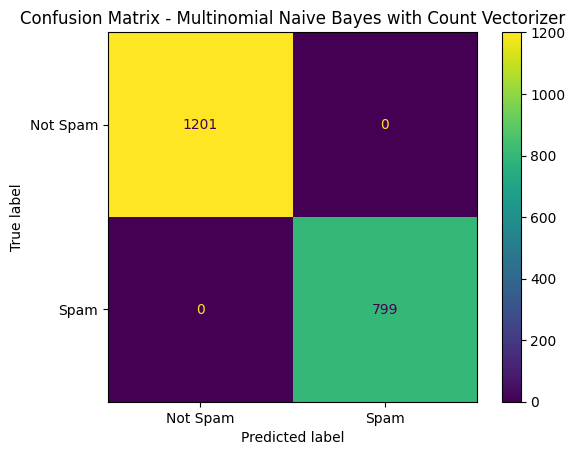

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_count = confusion_matrix(y_test, nb_pred_count)

print("Confusion Matrix:")
print(cm_count)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred_count,
    display_labels=['Not Spam', 'Spam']
)

plt.title("Confusion Matrix - Multinomial Naive Bayes with Count Vectorizer")
plt.show()

In [48]:
nb_model_tfidf = MultinomialNB()

nb_model_tfidf.fit(X_train_tfidf, y_train)

print("TF-IDF + Multinomial Naive Bayes training completed!")

TF-IDF + Multinomial Naive Bayes training completed!


In [49]:
nb_pred_tfidf = nb_model_tfidf.predict(X_test_tfidf)

print("Predictions:")
print(nb_pred_tfidf[:20])

Predictions:
[1 0 1 0 0 1 0 1 0 1 0 0 1 1 0 0 0 1 0 0]


In [50]:
nb_tfidf_accuracy = accuracy_score(y_test, nb_pred_tfidf)

print("TF-IDF + Multinomial Naive Bayes Accuracy:",
      nb_tfidf_accuracy)

print("Accuracy Percentage:",
      nb_tfidf_accuracy * 100, "%")

TF-IDF + Multinomial Naive Bayes Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [51]:
print(classification_report(
    y_test,
    nb_pred_tfidf,
    target_names=['Not Spam', 'Spam']
))

              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00      1201
        Spam       1.00      1.00      1.00       799

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



Confusion Matrix:
[[1201    0]
 [   0  799]]


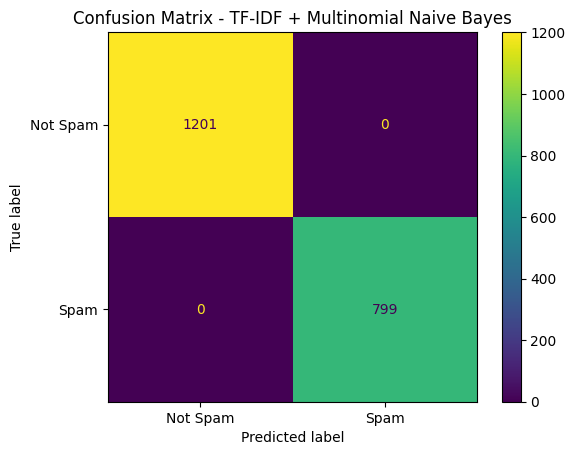

In [52]:
cm_tfidf = confusion_matrix(y_test, nb_pred_tfidf)

print("Confusion Matrix:")
print(cm_tfidf)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred_tfidf,
    display_labels=['Not Spam', 'Spam']
)

plt.title("Confusion Matrix - TF-IDF + Multinomial Naive Bayes")
plt.show()

In [53]:
print("CountVectorizer + Multinomial Naive Bayes:",
      nb_count_accuracy)

print("TF-IDF + Multinomial Naive Bayes:",
      nb_tfidf_accuracy)

CountVectorizer + Multinomial Naive Bayes: 1.0
TF-IDF + Multinomial Naive Bayes: 1.0


In [54]:
comparison = pd.DataFrame({
    'Vectorization': ['CountVectorizer', 'TF-IDF'],
    'Model': ['Multinomial Naive Bayes', 'Multinomial Naive Bayes'],
    'Accuracy': [nb_count_accuracy, nb_tfidf_accuracy]
})

comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

print(comparison)

     Vectorization                    Model  Accuracy  Accuracy (%)
0  CountVectorizer  Multinomial Naive Bayes       1.0         100.0
1           TF-IDF  Multinomial Naive Bayes       1.0         100.0


In [55]:
from sklearn.metrics import precision_score, recall_score, f1_score

count_precision = precision_score(y_test, nb_pred_count)
count_recall = recall_score(y_test, nb_pred_count)
count_f1 = f1_score(y_test, nb_pred_count)

tfidf_precision = precision_score(y_test, nb_pred_tfidf)
tfidf_recall = recall_score(y_test, nb_pred_tfidf)
tfidf_f1 = f1_score(y_test, nb_pred_tfidf)

comparison_metrics = pd.DataFrame({
    'Method': [
        'CountVectorizer + MultinomialNB',
        'TF-IDF + MultinomialNB'
    ],
    'Accuracy': [
        nb_count_accuracy,
        nb_tfidf_accuracy
    ],
    'Precision': [
        count_precision,
        tfidf_precision
    ],
    'Recall': [
        count_recall,
        tfidf_recall
    ],
    'F1-Score': [
        count_f1,
        tfidf_f1
    ]
})

print(comparison_metrics)

                            Method  Accuracy  Precision  Recall  F1-Score
0  CountVectorizer + MultinomialNB       1.0        1.0     1.0       1.0
1           TF-IDF + MultinomialNB       1.0        1.0     1.0       1.0


In [56]:
new_emails = [
    "Congratulations! You have won $5000. Click here now to claim your prize!",
    "Hi, I wanted to remind you about our meeting tomorrow at 10 AM.",
    "URGENT! You have been selected for a free cash reward. Claim now!",
    "Please send me the project report when you have time."
]

print("New emails:")
for email in new_emails:
    print("-", email)

New emails:
- Congratulations! You have won $5000. Click here now to claim your prize!
- Hi, I wanted to remind you about our meeting tomorrow at 10 AM.
- URGENT! You have been selected for a free cash reward. Claim now!
- Please send me the project report when you have time.


In [57]:
new_emails_clean = [
    preprocess_text(email)
    for email in new_emails
]

print("Cleaned emails:")
for email in new_emails_clean:
    print("-", email)

Cleaned emails:
- congratulations you have won click here now to claim your prize
- hi i wanted to remind you about our meeting tomorrow at am
- urgent you have been selected for a free cash reward claim now
- please send me the project report when you have time


In [58]:
new_emails_count = count_vectorizer.transform(new_emails_clean)

new_predictions_count = nb_model_count.predict(new_emails_count)

In [59]:
for email, prediction in zip(new_emails, new_predictions_count):
    if prediction == 1:
        print("Spam:", email)
    else:
        print("Not Spam:", email)

Spam: Congratulations! You have won $5000. Click here now to claim your prize!
Not Spam: Hi, I wanted to remind you about our meeting tomorrow at 10 AM.
Spam: URGENT! You have been selected for a free cash reward. Claim now!
Not Spam: Please send me the project report when you have time.


In [60]:
new_emails_tfidf = vectorizer.transform(new_emails_clean)

new_predictions_tfidf = nb_model_tfidf.predict(new_emails_tfidf)

for email, prediction in zip(new_emails, new_predictions_tfidf):
    if prediction == 1:
        print("Spam:", email)
    else:
        print("Not Spam:", email)

Spam: Congratulations! You have won $5000. Click here now to claim your prize!
Not Spam: Hi, I wanted to remind you about our meeting tomorrow at 10 AM.
Spam: URGENT! You have been selected for a free cash reward. Claim now!
Not Spam: Please send me the project report when you have time.


Confusion Matrix - CountVectorizer + MultinomialNB
[[1201    0]
 [   0  799]]


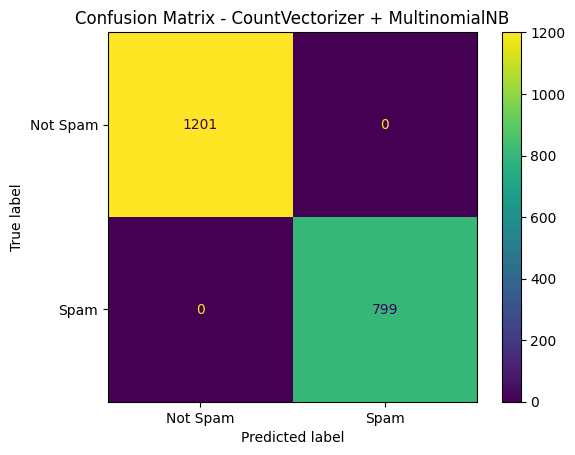

In [61]:
cm_count = confusion_matrix(y_test, nb_pred_count)

print("Confusion Matrix - CountVectorizer + MultinomialNB")
print(cm_count)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred_count,
    display_labels=['Not Spam', 'Spam']
)

plt.title("Confusion Matrix - CountVectorizer + MultinomialNB")
plt.show()

Confusion Matrix - TF-IDF + MultinomialNB
[[1201    0]
 [   0  799]]


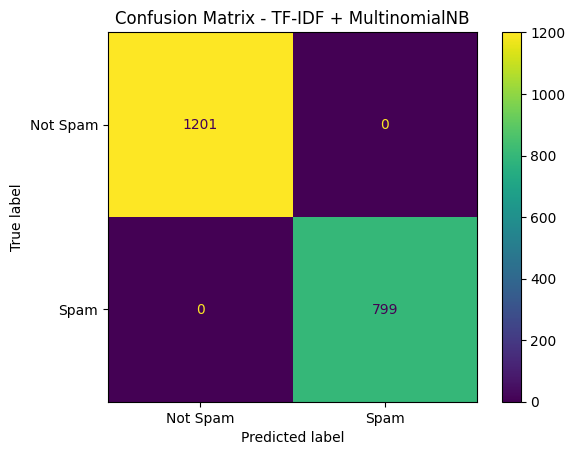

In [62]:
cm_tfidf = confusion_matrix(y_test, nb_pred_tfidf)

print("Confusion Matrix - TF-IDF + MultinomialNB")
print(cm_tfidf)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred_tfidf,
    display_labels=['Not Spam', 'Spam']
)

plt.title("Confusion Matrix - TF-IDF + MultinomialNB")
plt.show()

In [63]:
final_results = pd.DataFrame({
    'Method': [
        'CountVectorizer + MultinomialNB',
        'TF-IDF + MultinomialNB'
    ],
    'Accuracy': [
        nb_count_accuracy,
        nb_tfidf_accuracy
    ],
    'Precision': [
        count_precision,
        tfidf_precision
    ],
    'Recall': [
        count_recall,
        tfidf_recall
    ],
    'F1-Score': [
        count_f1,
        tfidf_f1
    ]
})

final_results['Accuracy'] = final_results['Accuracy'] * 100
final_results['Precision'] = final_results['Precision'] * 100
final_results['Recall'] = final_results['Recall'] * 100
final_results['F1-Score'] = final_results['F1-Score'] * 100

print(final_results)

                            Method  Accuracy  Precision  Recall  F1-Score
0  CountVectorizer + MultinomialNB     100.0      100.0   100.0     100.0
1           TF-IDF + MultinomialNB     100.0      100.0   100.0     100.0
